In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import warnings
warnings.filterwarnings('ignore')
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


In [3]:

url = "https://raw.githubusercontent.com/Efeyamann/LiverDiseaseAnalysis/main/Liver%20Patient%20Dataset%20(LPD)_train.csv"
try:
    df = pd.read_csv(url, encoding='latin1')
    print("Veri başarıyla çekildi (latin1 kullanıldı).")
except Exception as e:
    print(f"Hata devam ediyor: {e}")
print("Veri GitHub üzerinden başarıyla çekildi.")

Veri başarıyla çekildi (latin1 kullanıldı).
Veri GitHub üzerinden başarıyla çekildi.


In [9]:
turkce_basliklar = [
    'Yaş', 'Cinsiyet', 'Toplam_Bilirubin', 'Direkt_Bilirubin',
    'Alkali_Fosfataz', 'Alanin_Aminotransferaz', 'Aspartat_Aminotransferaz',
    'Toplam_Proteinler', 'Albümin', 'Albumin_Globulin_Orani', 'Sonuç'
]

df.columns = turkce_basliklar

print("--- VERİ SETİNİN İLK 5 SATIRI (TÜRKÇE) ---")
display(df.head())

print("\n--- VERİ SETİ ÖZETİ ---")
df.info()

--- VERİ SETİNİN İLK 5 SATIRI (TÜRKÇE) ---


,Yaş,Cinsiyet,Toplam_Bilirubin,Direkt_Bilirubin,Alkali_Fosfataz,Alanin_Aminotransferaz,Aspartat_Aminotransferaz,Toplam_Proteinler,Albümin,Albumin_Globulin_Orani,Sonuç
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1



--- VERİ SETİ ÖZETİ ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30691 entries, 0 to 30690
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Yaş                       30689 non-null  float64
 1   Cinsiyet                  29789 non-null  object 
 2   Toplam_Bilirubin          30043 non-null  float64
 3   Direkt_Bilirubin          30130 non-null  float64
 4   Alkali_Fosfataz           29895 non-null  float64
 5   Alanin_Aminotransferaz    30153 non-null  float64
 6   Aspartat_Aminotransferaz  30229 non-null  float64
 7   Toplam_Proteinler         30228 non-null  float64
 8   Albümin                   30197 non-null  float64
 9   Albumin_Globulin_Orani    30132 non-null  float64
 10  Sonuç                     30691 non-null  int64  
dtypes: float64(9), int64(1), object(1)
memory usage: 2.6+ MB


In [10]:
df['Albumin_Globulin_Orani'] = df['Albumin_Globulin_Orani'].fillna(df['Albumin_Globulin_Orani'].median())
df['Cinsiyet'] = df['Cinsiyet'].map({'Male': 1, 'Female': 0})
df['Sonuç'] = df['Sonuç'].map({1: 1, 2: 0})

X = df.drop('Sonuç', axis=1)
y = df['Sonuç']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Veri temizlendi ve eğitime hazır hale getirildi.")

Veri temizlendi ve eğitime hazır hale getirildi.


In [11]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("İki model de başarıyla eğitildi.")

İki model de başarıyla eğitildi.


Random Forest Başarısı: %99.07
XGBoost Başarısı:       %99.74


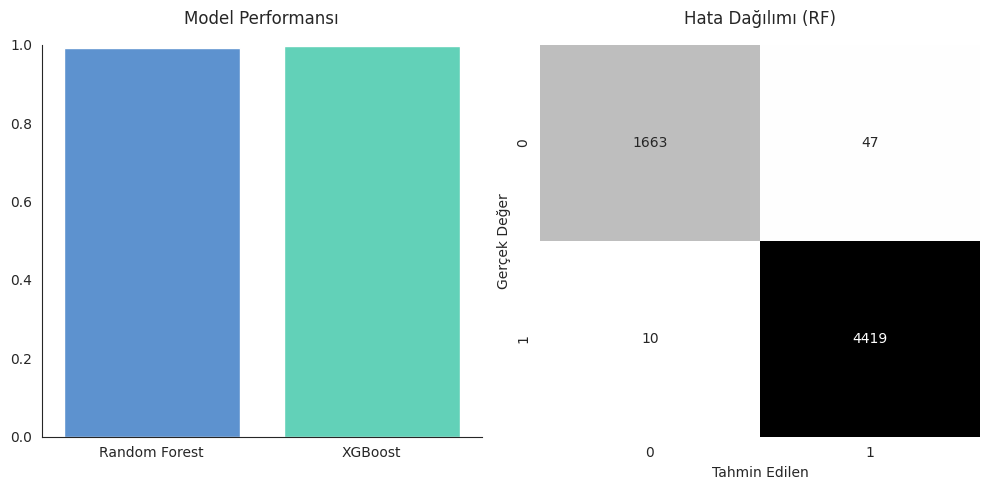

In [12]:
# Doğruluk
rf_acc = accuracy_score(y_test, rf_preds)
xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"Random Forest Başarısı: %{rf_acc*100:.2f}")
print(f"XGBoost Başarısı:       %{xgb_acc*100:.2f}")

plt.figure(figsize=(10, 5))
sns.set_style("white")

plt.subplot(1, 2, 1)
colors = ["#4A90E2", "#50E3C2"]
ax = sns.barplot(x=['Random Forest', 'XGBoost'], y=[rf_acc, xgb_acc], palette=colors)
plt.title('Model Performansı', fontsize=12, pad=15)
plt.ylim(0, 1)
sns.despine()

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greys', cbar=False)
plt.title('Hata Dağılımı (RF)', fontsize=12, pad=15)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')

plt.tight_layout()
plt.show();

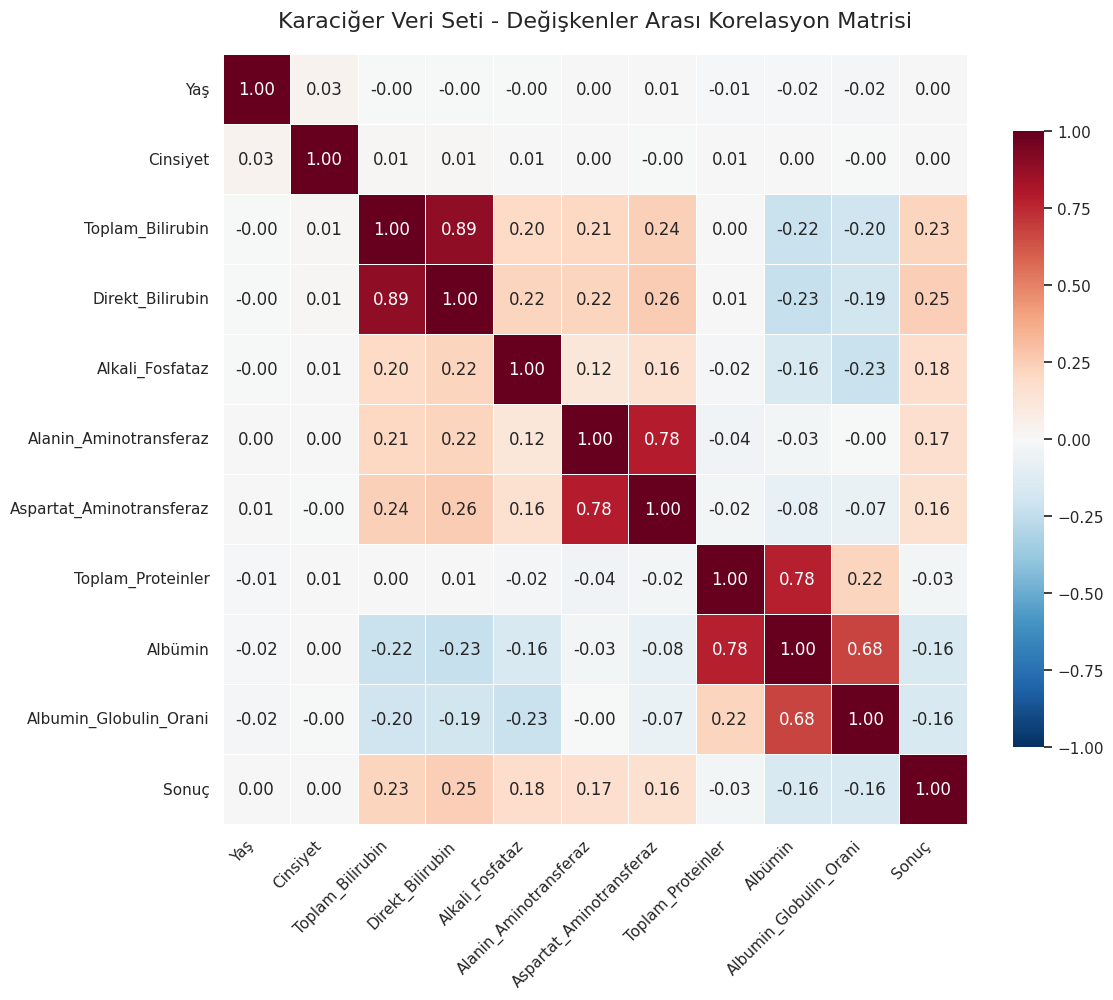

In [13]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.set_theme(style="white")


heatmap = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Karaciğer Veri Seti - Değişkenler Arası Korelasyon Matrisi', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()